In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/raw/ecommerce_customer_churn_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.head())

Shape: (50000, 25)
    Age  Gender Country        City  Membership_Years  Login_Frequency  \
0  43.0    Male  France   Marseille               2.9             14.0   
1  36.0    Male      UK  Manchester               1.6             15.0   
2  45.0  Female  Canada   Vancouver               2.9             10.0   
3  56.0  Female     USA    New York               2.6             10.0   
4  35.0    Male   India       Delhi               3.1             29.0   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0                  27.4                6.0                   50.6   
1                  42.7               10.3                   37.7   
2                  24.8                1.6                   70.9   
3                  38.4               14.8                   41.7   
4                  51.4                NaN                   19.1   

   Wishlist_Items  ...  Email_Open_Rate  Customer_Service_Calls  \
0             3.0  ...             17.9               

## Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

## Statistical summary

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000
Pages_Per_Session,47000.0,8.737811,3.778220,1.00,6.0000,8.400,11.20,24.100000
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350
Wishlist_Items,46000.0,4.298391,3.189754,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,50000.0,13.111576,7.017312,-13.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000


- Total_Purchases contains negative values, with a minimum of -13. Since purchase count cannot logically be negative, these records will require handling during preprocessing.

## Check null values

In [5]:
df.isnull().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

Several numerical features contain missing values, with the highest missingness observed in Social_Media_Engagement_Score (12%), Credit_Balance (11%), and Mobile_App_Usage (10%). The target variable Churned contains no missing values. Since the missing values are concentrated in numerical features and are within a manageable range, the affected features will be retained and missing values will be handled during preprocessing

## Duplicate check

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.nunique()

Age                                 62
Gender                               3
Country                              8
City                                40
Membership_Years                   200
Login_Frequency                     46
Session_Duration_Avg               658
Pages_Per_Session                  224
Cart_Abandonment_Rate             1000
Wishlist_Items                      25
Total_Purchases                    150
Average_Order_Value              16407
Days_Since_Last_Purchase           235
Discount_Usage_Rate               1727
Returns_Rate                       394
Email_Open_Rate                    720
Customer_Service_Calls              21
Product_Reviews_Written             18
Social_Media_Engagement_Score      972
Mobile_App_Usage                   540
Payment_Method_Diversity             5
Lifetime_Value                   45447
Credit_Balance                    5234
Churned                              2
Signup_Quarter                       4
dtype: int64

In [8]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'City',
 'Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 'Churned',
 'Signup_Quarter']

## target Variable Analysis

In [9]:
df["Churned"].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

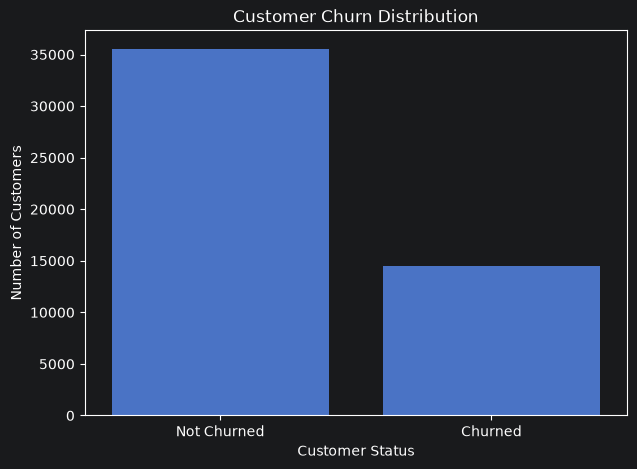

In [10]:

churn_counts = df["Churned"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=["Not Churned", "Churned"],
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()

## Univariate Analysis

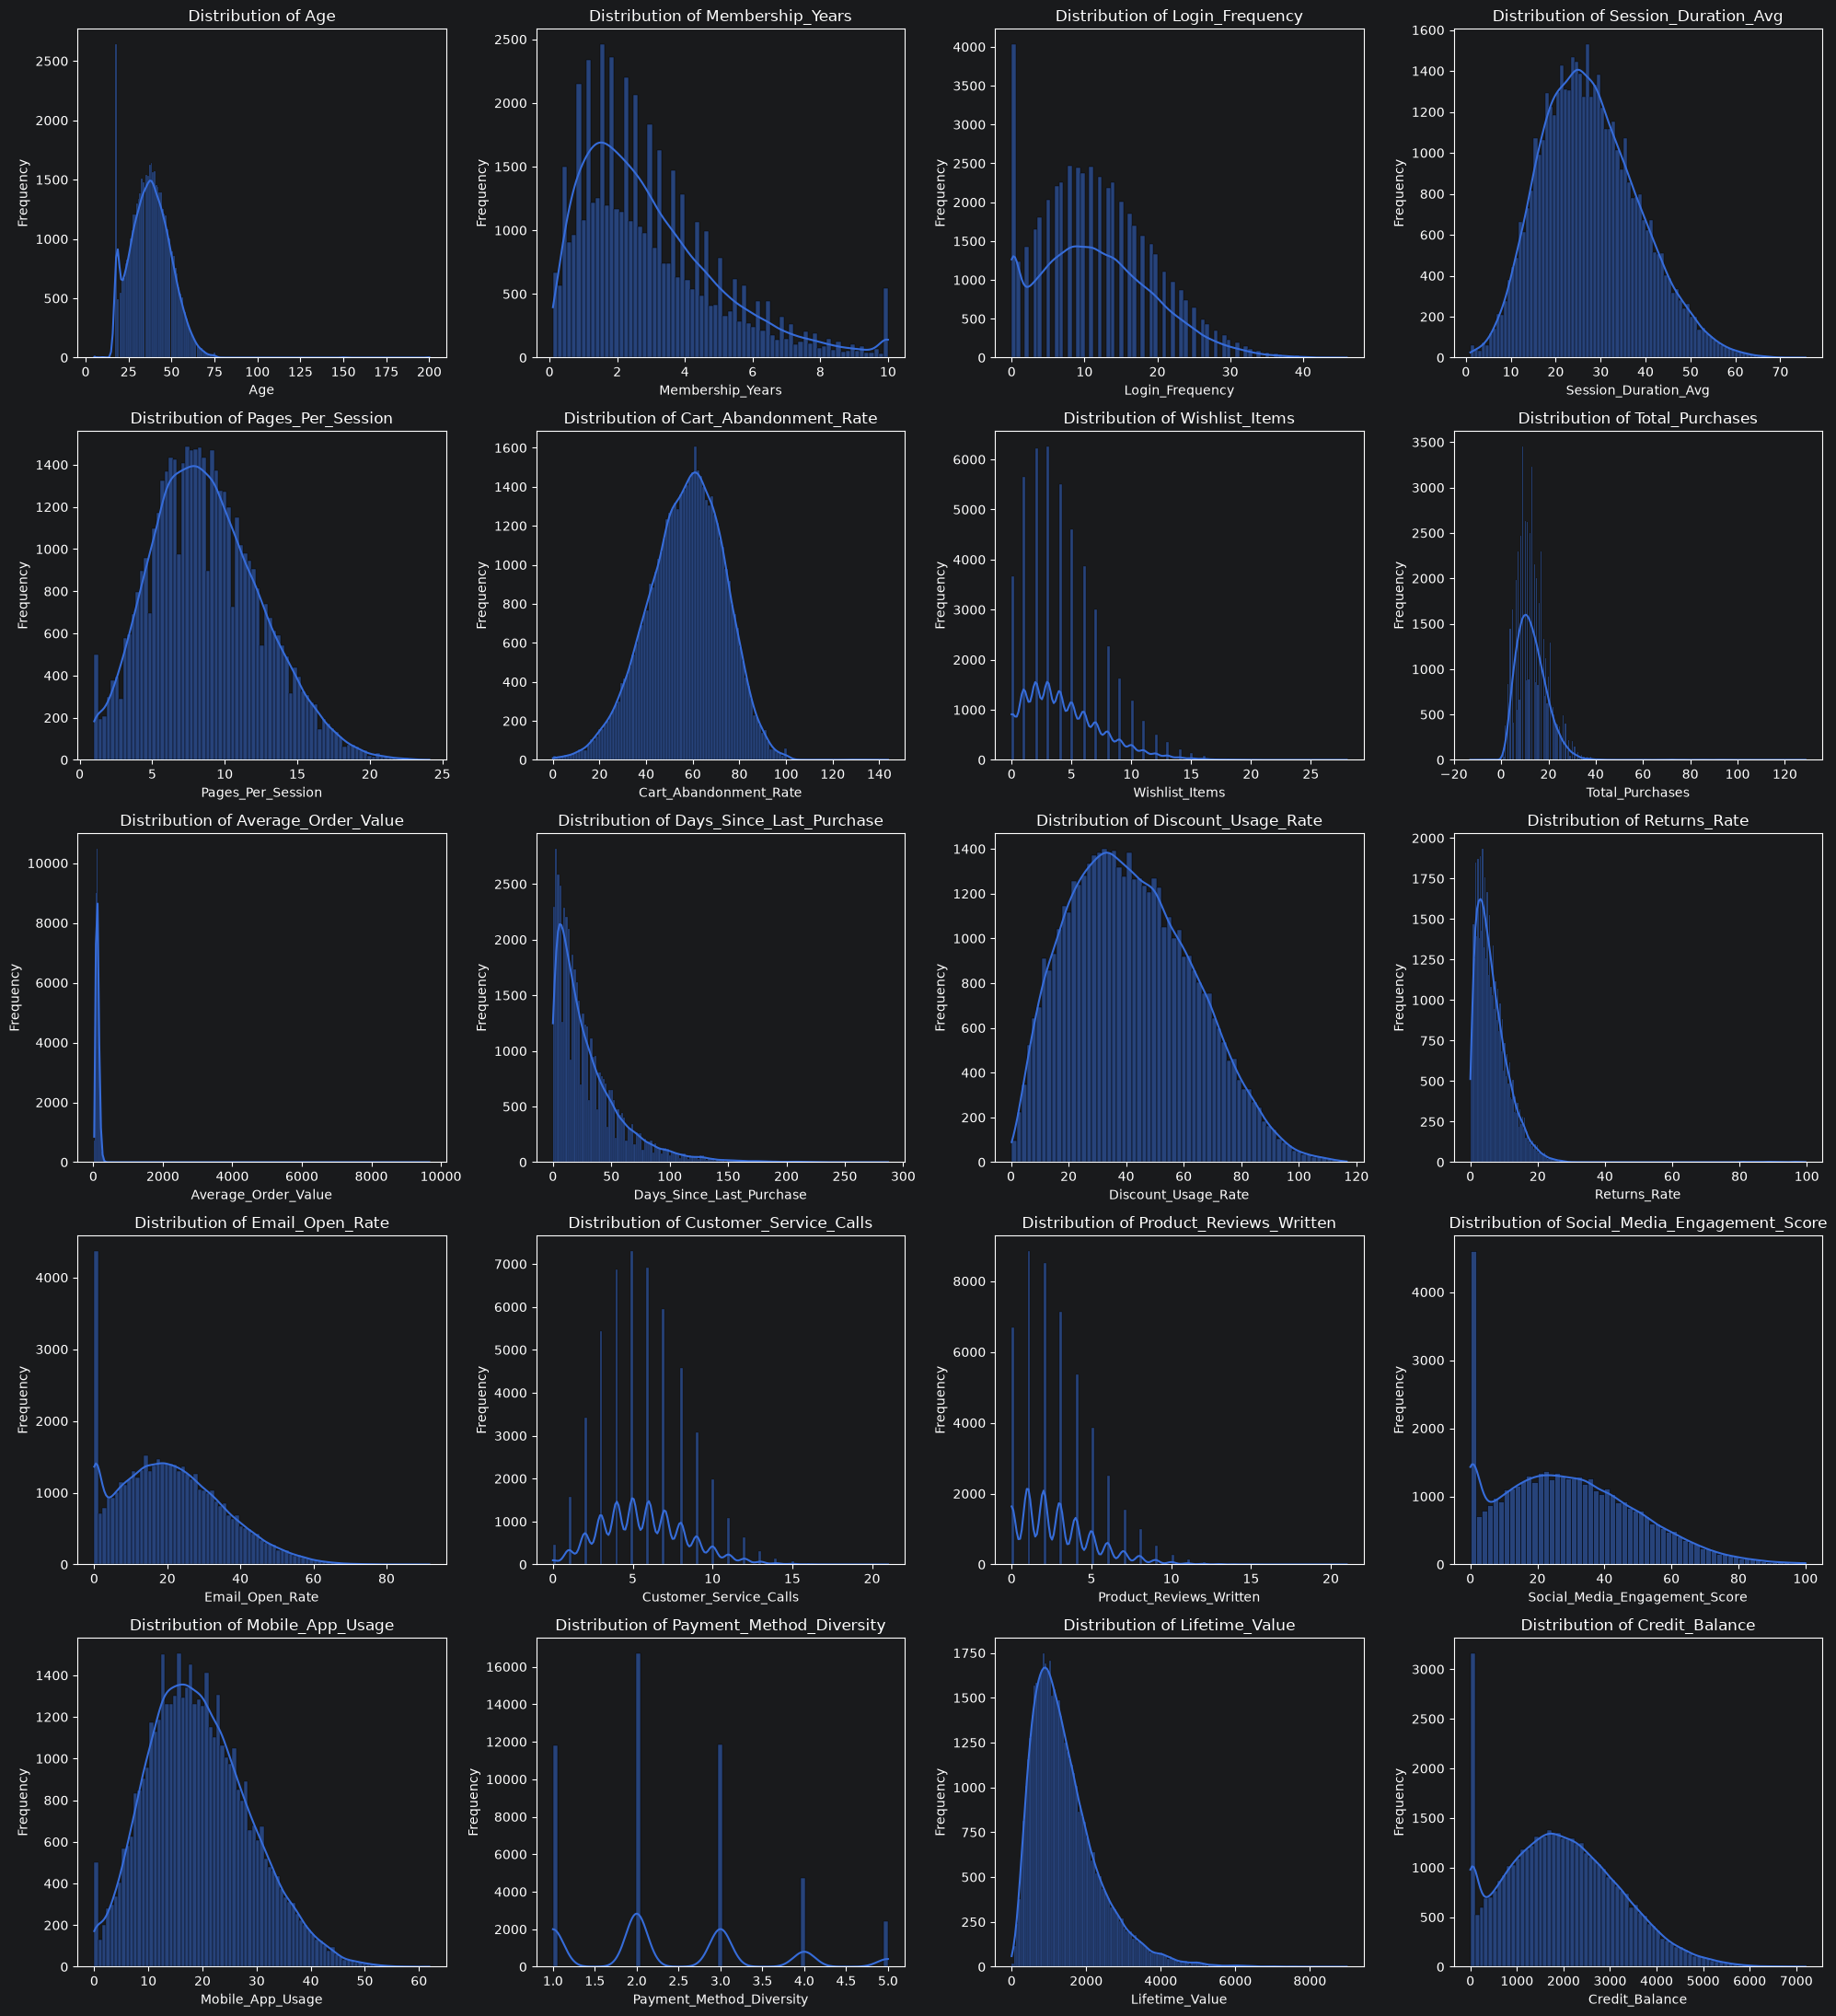

In [11]:
numerical_cols = df.select_dtypes(include="number").columns
numerical_cols = numerical_cols.drop("Churned")

fig, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(20, 22)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Outilier Detection

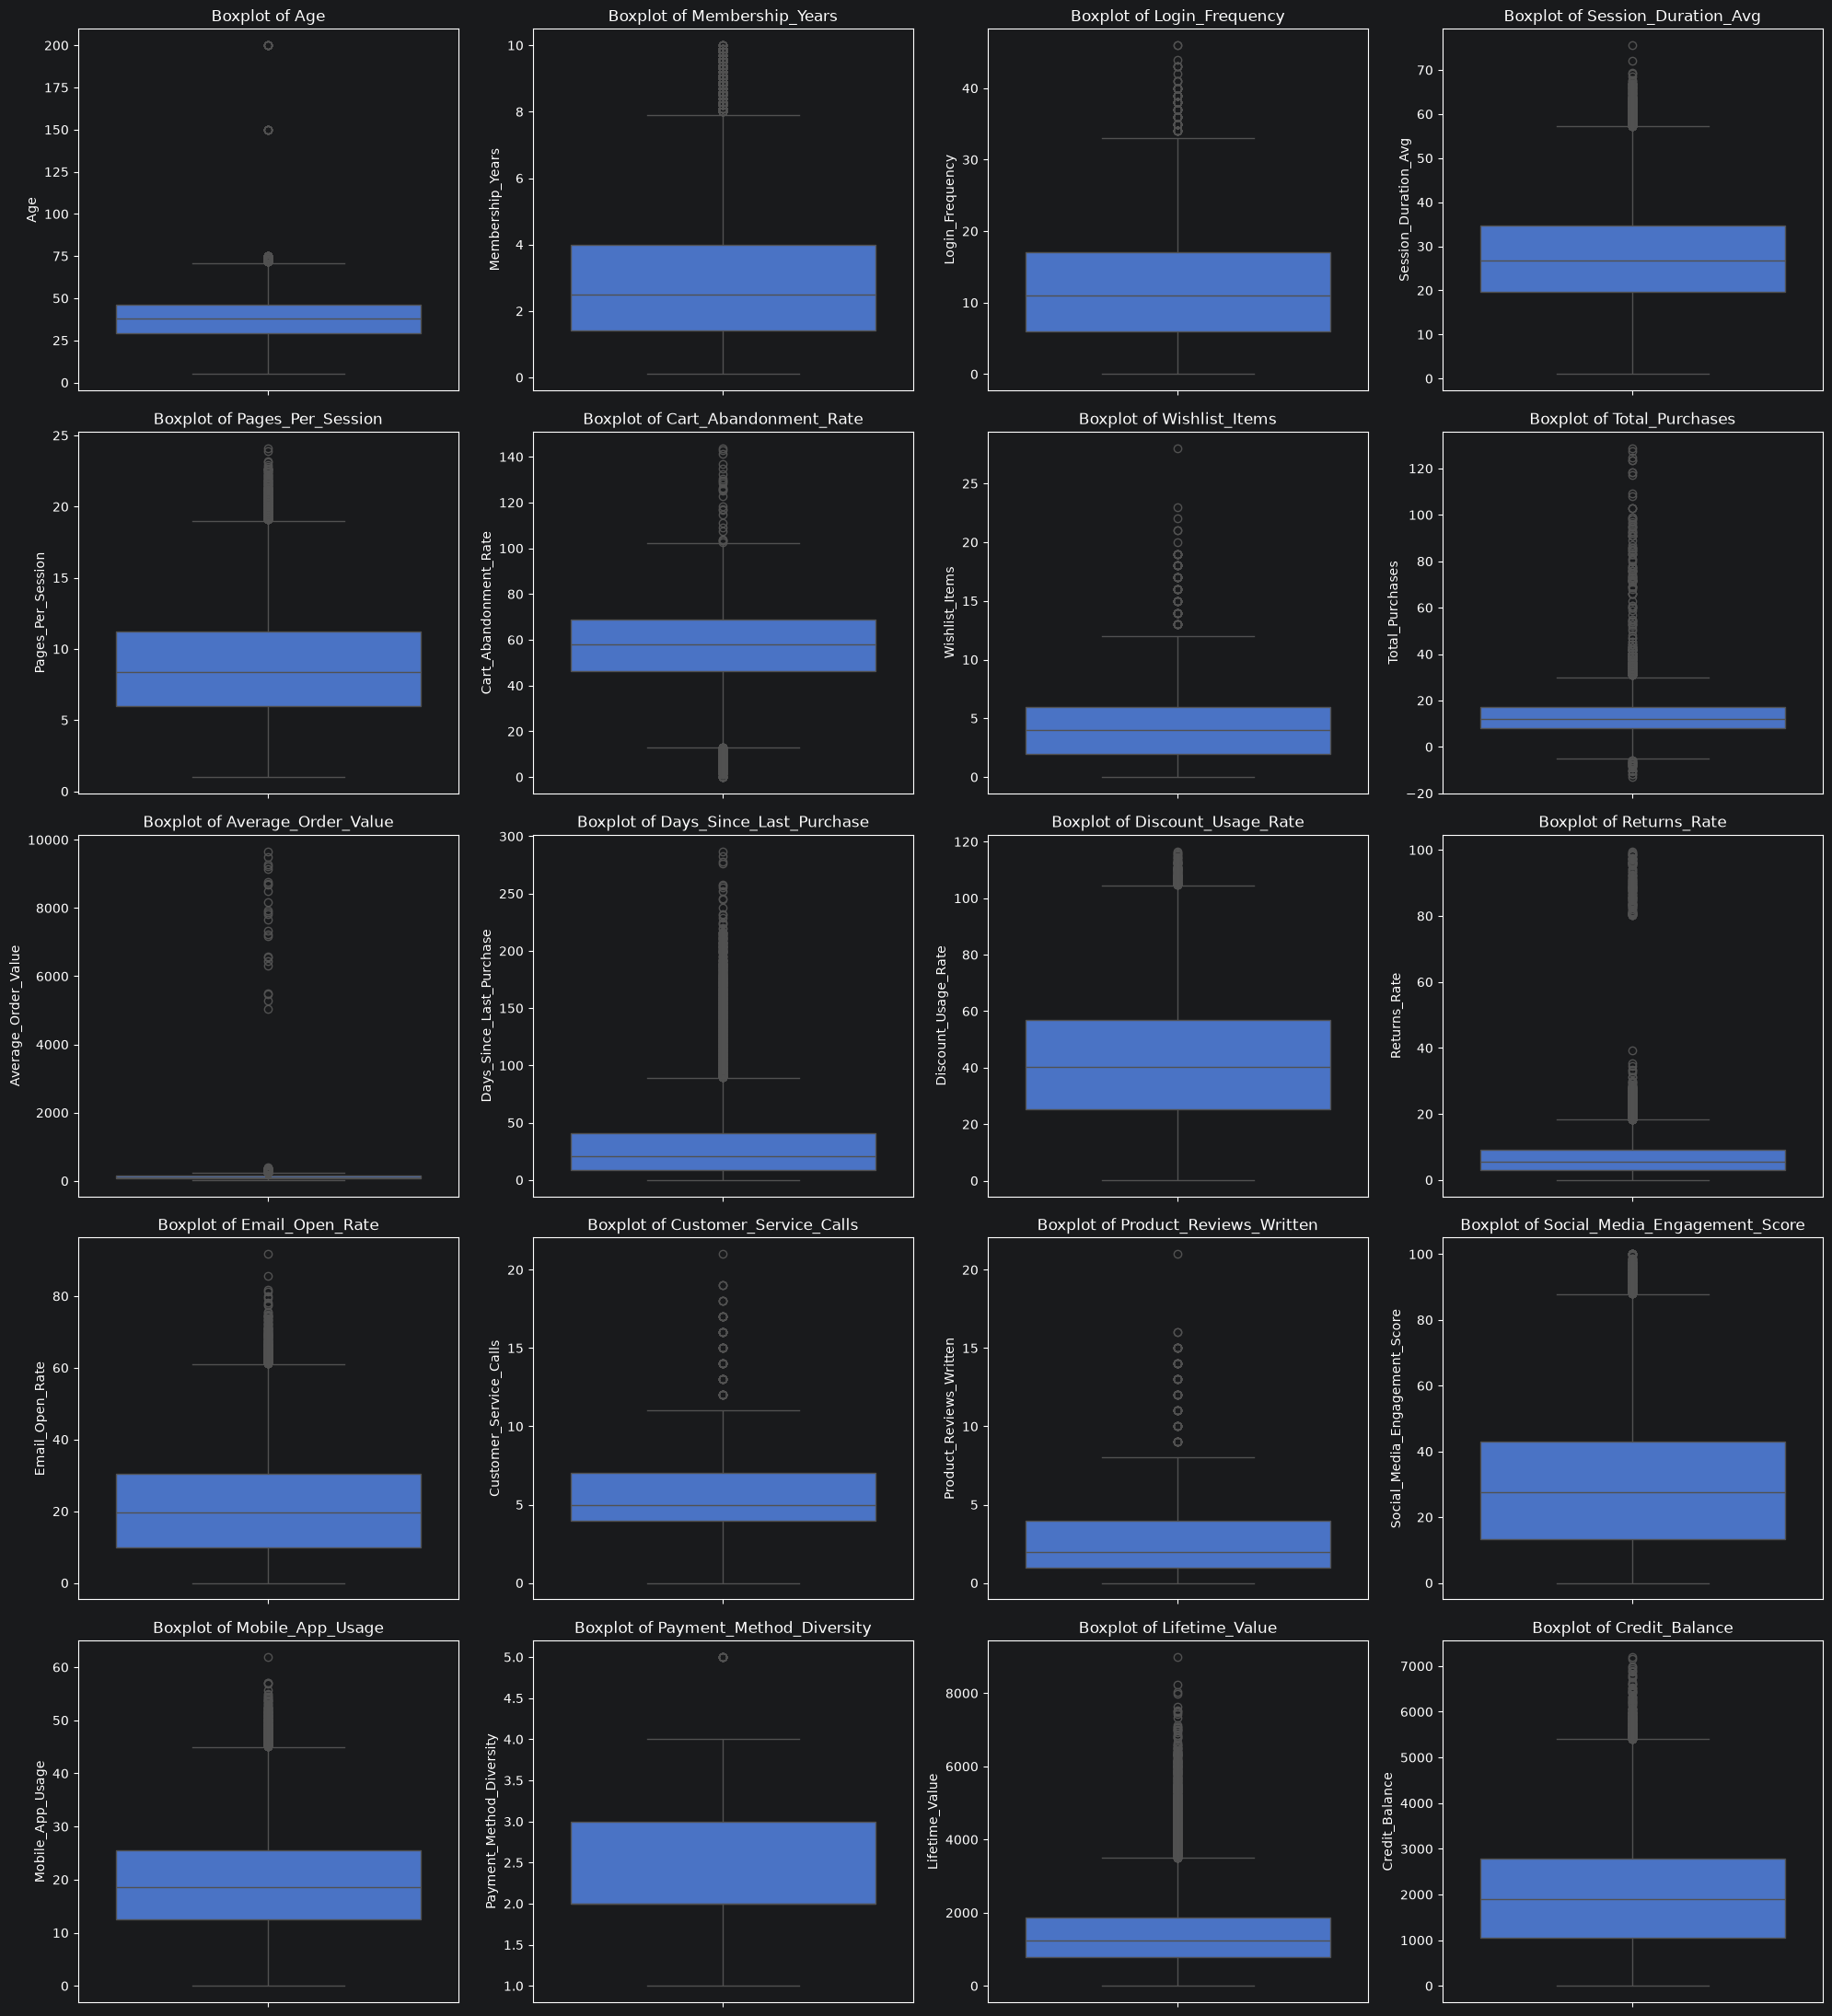

In [12]:
fig, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(20, 22)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Several numerical variables exhibit potential outliers, particularly Average_Order_Value, Lifetime_Value, Total_Purchases, and Days_Since_Last_Purchase. These observations will be investigated further before deciding on an appropriate treatment strategy

In [13]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Gender: 3 unique values
Country: 8 unique values
City: 40 unique values
Signup_Quarter: 4 unique values


C:\Users\USER\AppData\Local\Temp\ipykernel_19240\3928630779.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


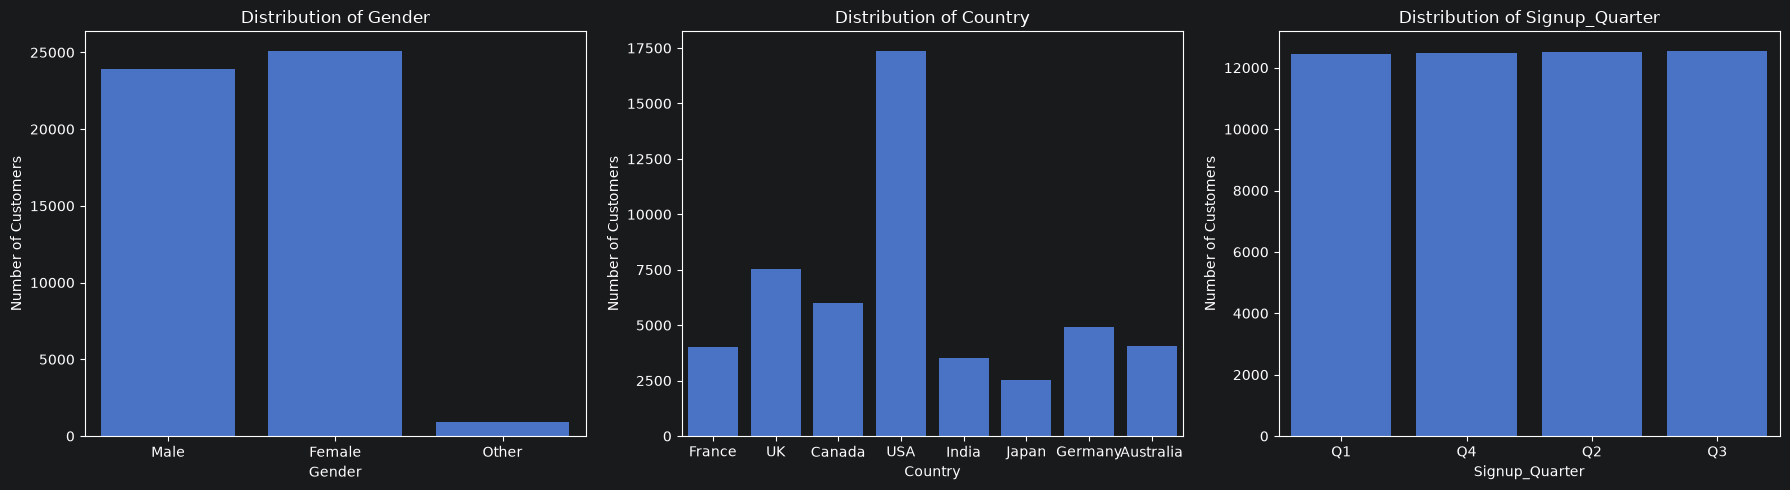

In [14]:
categorical_cols = ["Gender", "Country", "Signup_Quarter"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5)
)

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

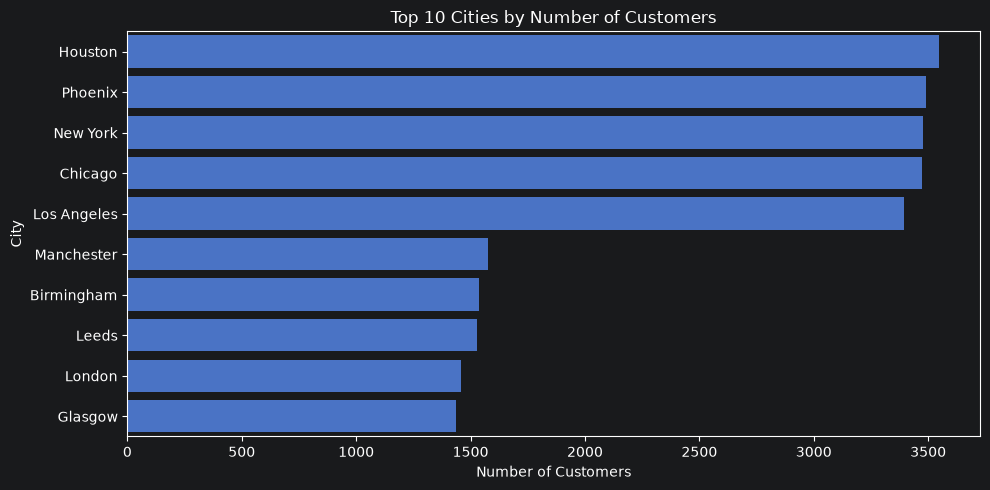

In [15]:
top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Cities by Number of Customers")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.tight_layout()
plt.show()

## Bivariate Analysis

### Numerical VS Churned

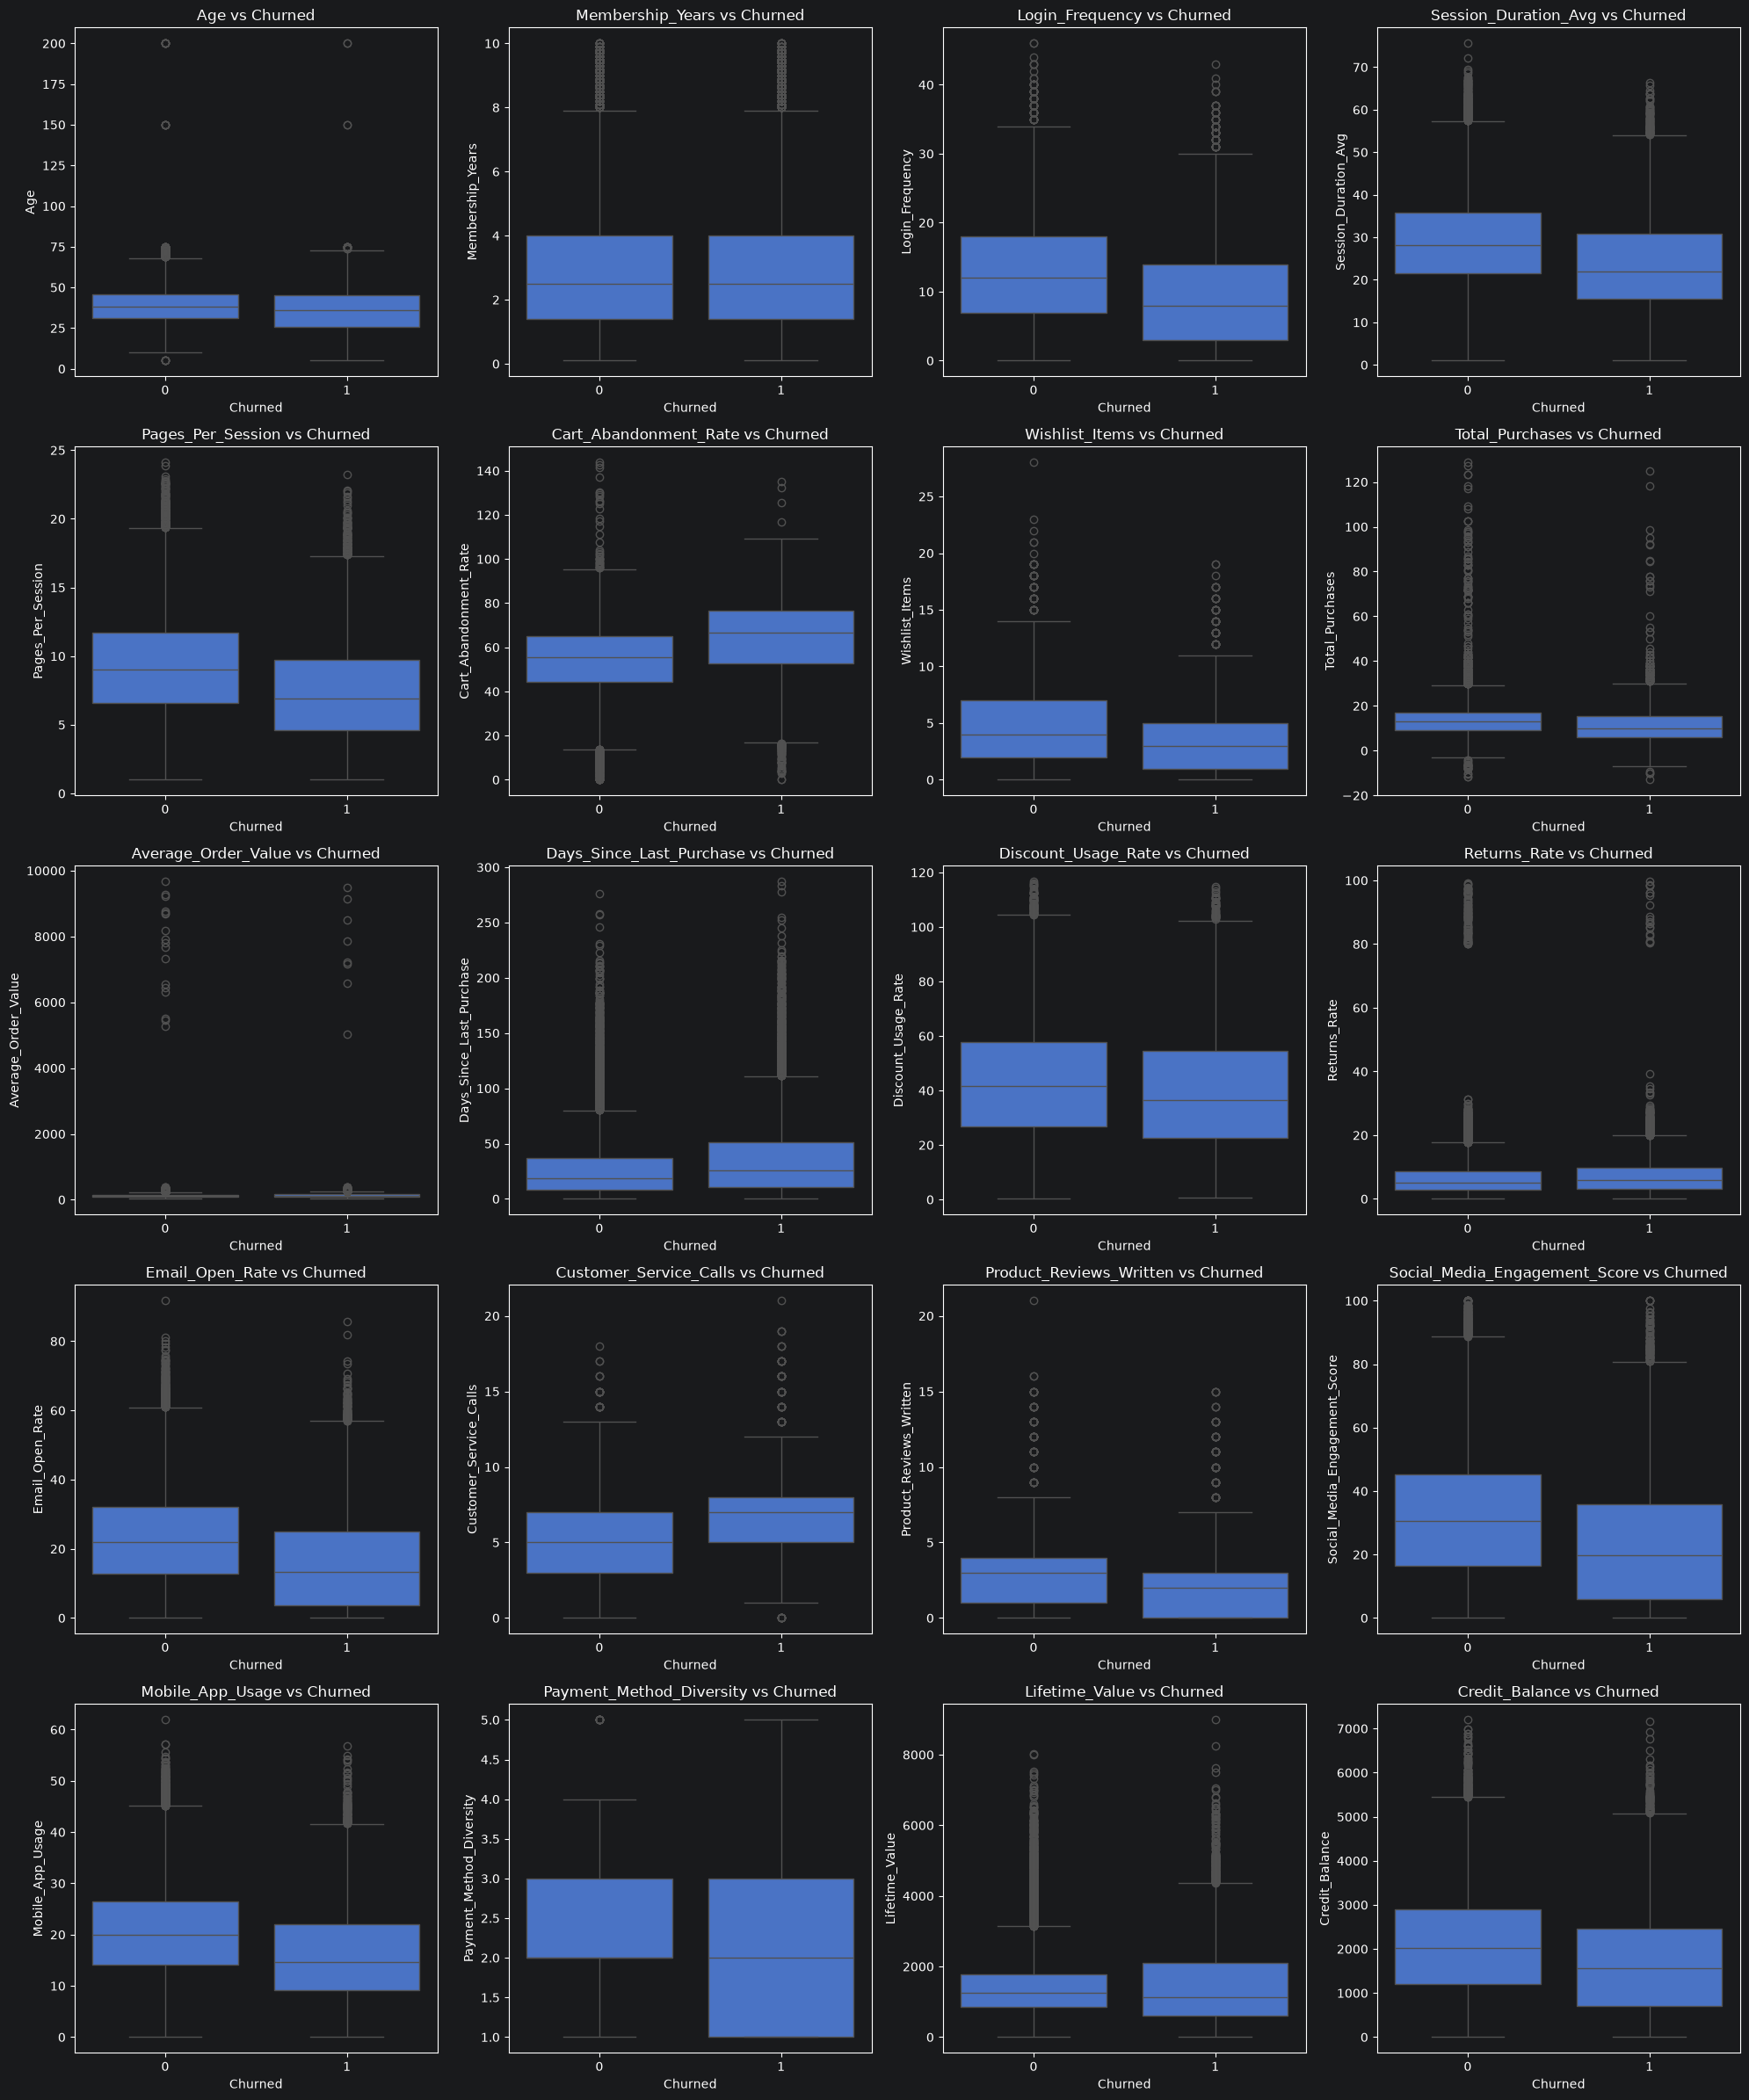

In [16]:
numerical_cols = df.select_dtypes(include="number").columns
numerical_cols = numerical_cols.drop("Churned")

fig, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(20, 24)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        data=df,
        x="Churned",
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Churned")
    axes[i].set_xlabel("Churned")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [17]:
group_stats = df.groupby("Churned")[numerical_cols].mean().T

print(group_stats)

Churned                                  0            1
Age                              38.582557    35.902598
Membership_Years                  2.984828     2.981996
Login_Frequency                  12.642391     9.120830
Session_Duration_Avg             29.206784    23.686822
Pages_Per_Session                 9.297002     7.366206
Cart_Abandonment_Rate            54.194460    64.178935
Wishlist_Items                    4.700410     3.309133
Total_Purchases                  13.827522    11.350201
Average_Order_Value             118.383907   134.762532
Days_Since_Last_Purchase         26.892026    36.942135
Discount_Usage_Rate              43.053423    39.424370
Returns_Rate                      6.469185     7.204272
Email_Open_Rate                  22.926396    15.893608
Customer_Service_Calls            5.185458     6.904378
Product_Reviews_Written           3.121839     2.189940
Social_Media_Engagement_Score    31.873633    23.159184
Mobile_App_Usage                 20.710595    16

In [18]:
median_stats = df.groupby("Churned")[numerical_cols].median().T

print(median_stats)

Churned                               0         1
Age                              38.000    36.000
Membership_Years                  2.500     2.500
Login_Frequency                  12.000     8.000
Session_Duration_Avg             28.200    22.000
Pages_Per_Session                 9.000     6.900
Cart_Abandonment_Rate            55.500    66.600
Wishlist_Items                    4.000     3.000
Total_Purchases                  13.000    10.000
Average_Order_Value             108.935   124.395
Days_Since_Last_Purchase         19.000    26.000
Discount_Usage_Rate              41.600    36.400
Returns_Rate                      5.200     6.000
Email_Open_Rate                  21.900    13.400
Customer_Service_Calls            5.000     7.000
Product_Reviews_Written           3.000     2.000
Social_Media_Engagement_Score    30.500    19.900
Mobile_App_Usage                 20.000    14.700
Payment_Method_Diversity          2.000     2.000
Lifetime_Value                 1266.790  1132.730


### Categorical VS churned

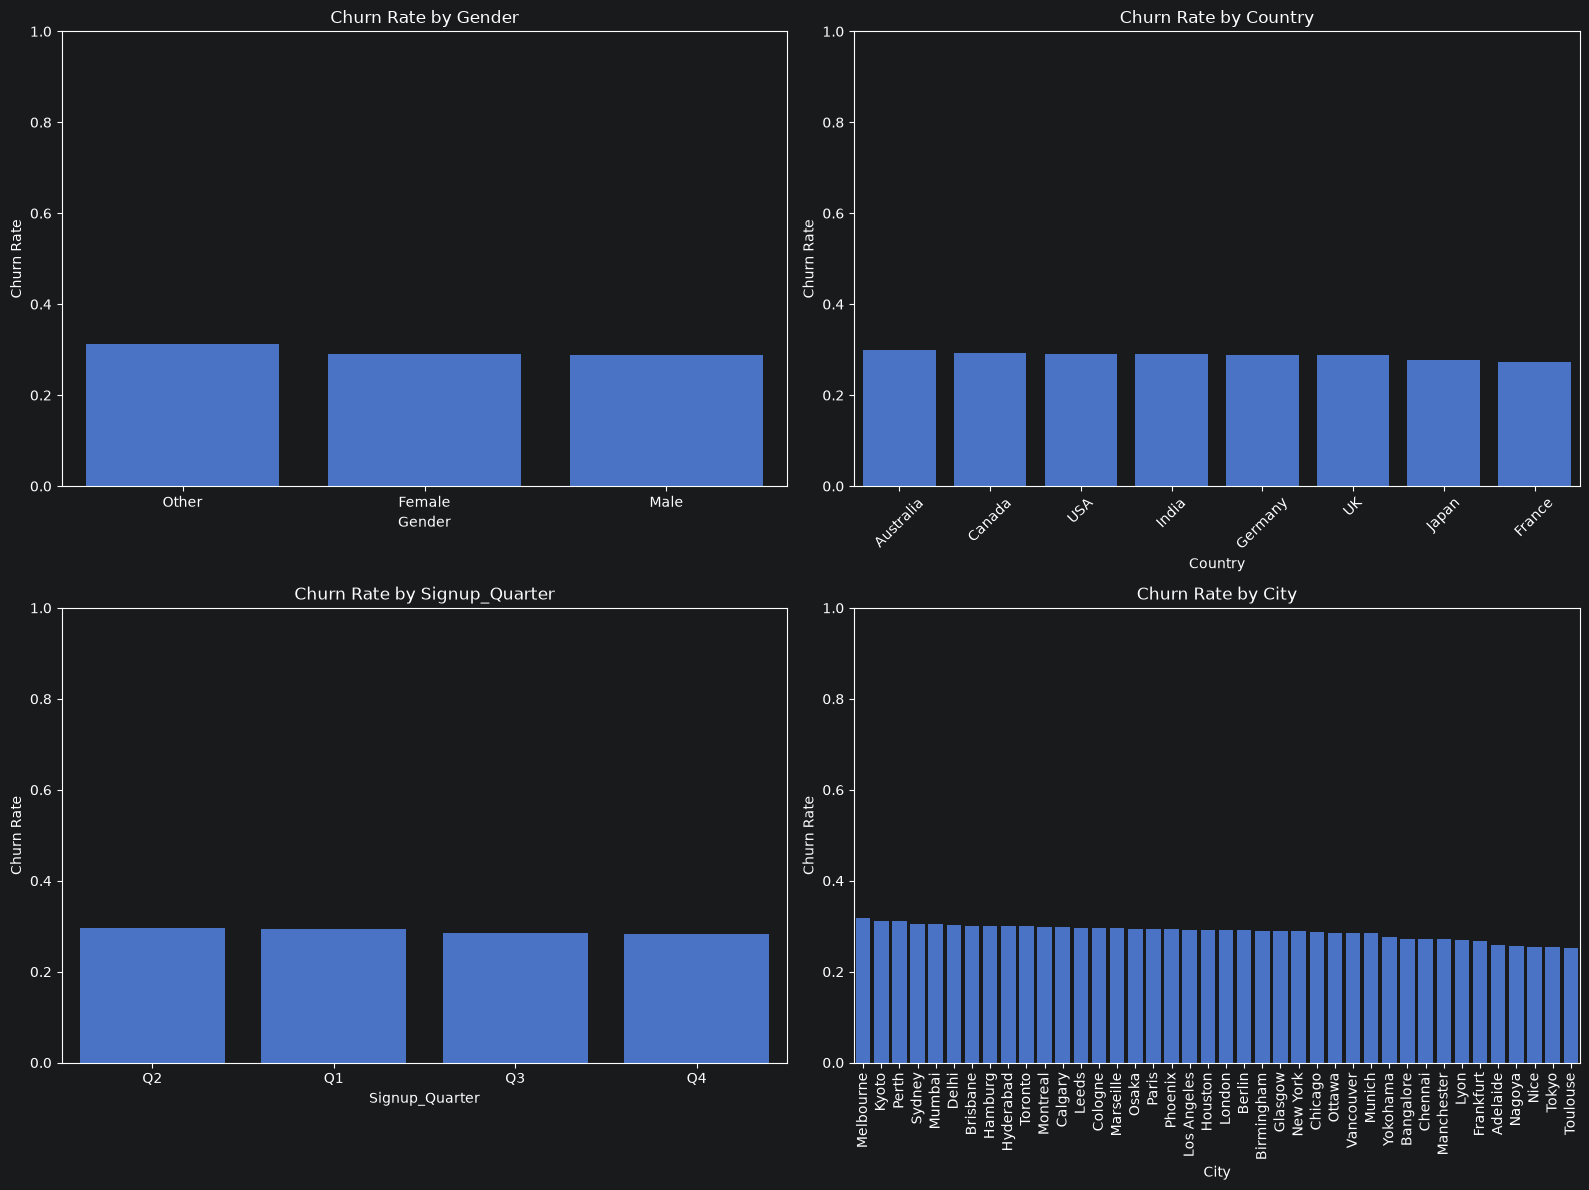

In [19]:
categorical_cols = ["Gender", "Country", "Signup_Quarter", "City"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    churn_rate = (
        df.groupby(col)["Churned"]
        .mean()
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values,
        ax=axes[i]
    )

    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_ylim(0, 1)

    if col == "City":
        axes[i].tick_params(axis="x", rotation=90)
    elif col == "Country":
        axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [20]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(
        df.groupby(col)["Churned"]
        .mean()
        .sort_values(ascending=False)
    )


--- Gender ---
Gender
Other     0.312700
Female    0.289736
Male      0.287301
Name: Churned, dtype: float64

--- Country ---
Country
Australia    0.298941
Canada       0.293541
USA          0.290842
India        0.290148
Germany      0.288325
UK           0.287895
Japan        0.278257
France       0.272863
Name: Churned, dtype: float64

--- Signup_Quarter ---
Signup_Quarter
Q2    0.296702
Q1    0.293182
Q3    0.284281
Q4    0.281842
Name: Churned, dtype: float64

--- City ---
City
Melbourne      0.318012
Kyoto          0.311637
Perth          0.310894
Sydney         0.305556
Mumbai         0.305476
Delhi          0.303030
Brisbane       0.301008
Hamburg        0.300195
Hyderabad      0.299566
Toronto        0.299421
Montreal       0.299118
Calgary        0.299003
Leeds          0.296926
Cologne        0.295257
Marseille      0.295082
Osaka          0.294355
Paris          0.293814
Phoenix        0.293410
Los Angeles    0.292072
Houston        0.291631
London         0.291495
Berlin 

## Correlation Heatmap

In [21]:
correlation_matrix = df.corr(numeric_only=True)

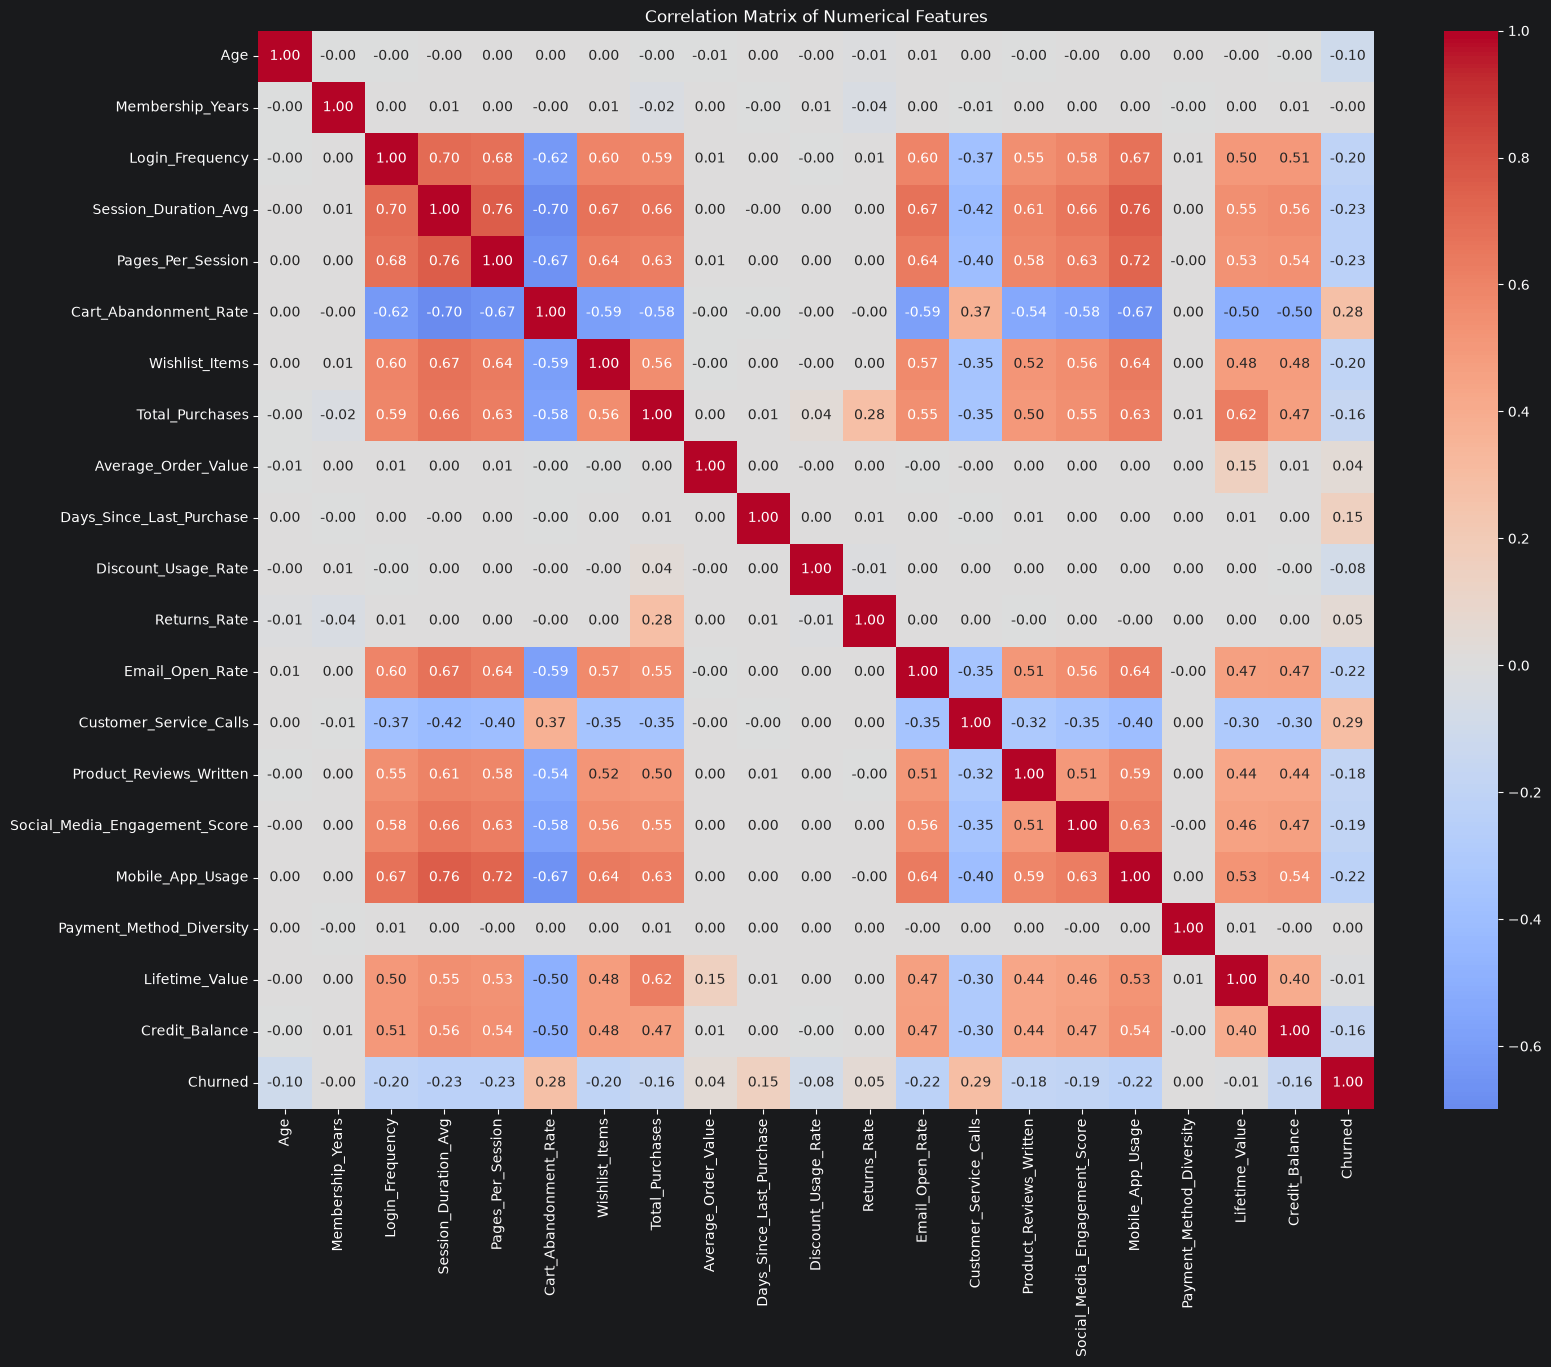

In [22]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

Correlation analysis showed that no numerical feature had a strong linear correlation with the churn target. Customer_Service_Calls (0.291) and Cart_Abandonment_Rate (0.278) had the strongest positive correlations with churn. Several customer engagement features showed moderate negative associations with churn. Features with weak correlation were retained because correlation alone does not determine their usefulness for machine-learning models.

### Key Finidngs:
The dataset contains 50,000 customer records and 25 features.
The target variable Churned has two classes, with 28.9% churned customers and 71.1% non-churned customers.
Several numerical features contain missing values, with the highest missingness in Social_Media_Engagement_Score (12%), Credit_Balance (11%), and Mobile_App_Usage (10%).
No duplicate rows were identified.
Numerical features show varying degrees of skewness and several potential outliers, particularly in customer spending, purchase, and behavioral variables.
Customer_Service_Calls and Cart_Abandonment_Rate have the strongest positive linear associations with churn.
Several engagement-related features show negative associations with churn.
Categorical variables show relatively modest differences in churn rates, although some variation exists across cities.
Correlation analysis alone was not used to remove features; feature usefulness will be evaluated during model development.